# E05 Matrix Sensing Sample-Complexity Phase Diagram

### Problem

This notebook studies how Matrix Sensing recovery changes with sample complexity. The noiseless observations are

$$y_i=\langle A_i,X^\star\rangle,\qquad i=1,\ldots,m,$$

and the optimization variable $X\in\mathbb{R}^{d\times d}$ minimizes

$$f(X)=\frac{1}{2m}\sum_{i=1}^{m}(\langle A_i,X\rangle-y_i)^2.$$

The target distribution is $X^\star=U\operatorname{diag}(s)V^\top$ with Gaussian QR singular vectors. This notebook compares `hard-k1`, `poly-k10`, `poly-k100`, `exp-k10`, and `exp-k100`, with fixed rank $r=5$. When `kappa>1`, the implementation sets the nonzero singular values to a linear grid between $1$ and $1/\kappa$.

Measurements are Gaussian and the number of measurements is controlled by `m_multiplier`, written as $\alpha$:

$$A_i[j,k]\overset{\mathrm{i.i.d.}}{\sim}\mathcal{N}(0,1),\qquad m=\alpha dr,\qquad \alpha\in\{1,2,3,4,6,8\}.$$

There is no observation noise. The initialization is

$$X_0=s_{\mathrm{init}}G_0,\qquad G_0[j,k]\overset{\mathrm{i.i.d.}}{\sim}\mathcal{N}(0,1),\qquad s_{\mathrm{init}}=10^{-2}.$$

The experiment fixes $d=60$, $r=5$, measurement law, noise level, and initialization scale; it varies sample-complexity factor $\alpha$, spectrum/conditioning, optimizer, and seed. Its purpose is to see whether more measurements improve actual recovery and whether optimizers differ in the undersampled or ill-conditioned regimes.

When reading the results, focus first on recovery error $e(\widehat X)=\lVert\widehat X-X^\star\rVert_F/\lVert X^\star\rVert_F$, not just training loss. Then read success/divergence rates and Muon-vs-baseline gap heatmaps to locate regimes where methods separate. Per-step work scales as $\Theta(md^2)=\Theta(\alpha rd^3)$, so larger $\alpha$ is both statistically easier and computationally more expensive; the full grid can execute up to $15000000$ optimization steps.

## Implementation Details: Skip Unless Modifying The Experiment

The code below is visible for reproducibility. A reader can skip it unless changing the grid, optimizer definitions, stopping rule, diagnostics, or plotting calls.

In [1]:
import math
import os
import pathlib
import sys
import time
for name in ["OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS", "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"]:
    os.environ.setdefault(name, "1")

import IPython.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

PROJECT = pathlib.Path.cwd().resolve()
if not (PROJECT / "problems").exists():
    PROJECT = PROJECT.parent.resolve()
sys.path.insert(0, str(PROJECT))

import optimizers
import plotting
import problems.MatrixConstruction
import problems.MatrixSensing
import util
import util.diagnostics

torch.set_default_dtype(torch.float64)
torch.set_num_threads(1)
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass

print(f"project = {PROJECT}")
print(f"torch   = {torch.__version__}")


project = /Users/tianyangliu/Desktop/muonexperiment
torch   = 2.11.0


/opt/anaconda3/envs/muonexperiment-torch/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Parameters And Runs


In [2]:
NOTEBOOK_ID = "E05 sample complexity"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE_NAME = "float64"
ALGOS = ["Muon", "Muon-Exact", "Shampoo", "Adam", "SGD"]
SEEDS = list(range(50))
SMOKE_TEST = False
SMOKE_TEST_MAX_STEPS = 10
FULL_ITERS = 2000
SUCCESS_THRESHOLD = 1e-2

BASE_SPEC = dict(
    problem="MatrixSensing",
    d=60,
    rank=5,
    lr=0.01,
    noise=0.0,
    dist="normal",
    init_scale=0.01,
    iters=SMOKE_TEST_MAX_STEPS if SMOKE_TEST else FULL_ITERS,
    early_stop=True,
    early_stop_min_steps=20,
    early_stop_patience=20,
    early_stop_min_delta=1e-3,
    device_type=DEVICE.type,
    dtype_name=DTYPE_NAME,
)
SPECTRUM_CASES = [
    dict(spectrum_case="hard-k1", spectrum="hard-cutoff", kappa=1.0),
    dict(spectrum_case="poly-k10", spectrum="polynomial-decay", kappa=10.0),
    dict(spectrum_case="poly-k100", spectrum="polynomial-decay", kappa=100.0),
    dict(spectrum_case="exp-k10", spectrum="exponential-decay", kappa=10.0),
    dict(spectrum_case="exp-k100", spectrum="exponential-decay", kappa=100.0),
]
M_MULTIPLIERS = [1, 2, 3, 4, 6, 8]
NUM_WORKERS = min(8, os.cpu_count() or 1)
JOBLIB_BACKEND = "loky"

runs = pd.DataFrame([
    {**BASE_SPEC, **case, "m_multiplier": m_multiplier, "algo": algo, "seed": seed}
    for case in SPECTRUM_CASES
    for m_multiplier in M_MULTIPLIERS
    for algo in ALGOS
    for seed in SEEDS
])
runs.insert(0, "run_id", range(len(runs)))

print(f"device={DEVICE}, workers={NUM_WORKERS}, backend={JOBLIB_BACKEND}")
print(f"smoke_test={SMOKE_TEST}, steps_per_run={BASE_SPEC['iters']}")
print(f"runs={len(runs)}, max_total_steps={len(runs) * BASE_SPEC['iters']}")
IPython.display.display(runs)


device=cpu, workers=8, backend=loky
smoke_test=False, steps_per_run=2000
runs=750, max_total_steps=1500000


,run_id,problem,d,rank,lr,noise,dist,init_scale,iters,early_stop,...,early_stop_patience,early_stop_min_delta,device_type,dtype_name,spectrum_case,spectrum,kappa,m_multiplier,algo,seed
0,0,MatrixSensing,60,5,0.01,0.0,normal,0.01,2000,True,...,20,0.001,cpu,float64,hard-k1,hard-cutoff,1.0,1,Muon,0
1,1,MatrixSensing,60,5,0.01,0.0,normal,0.01,2000,True,...,20,0.001,cpu,float64,hard-k1,hard-cutoff,1.0,1,Muon,1
2,2,MatrixSensing,60,5,0.01,0.0,normal,0.01,2000,True,...,20,0.001,cpu,float64,hard-k1,hard-cutoff,1.0,1,Muon,2
3,3,MatrixSensing,60,5,0.01,0.0,normal,0.01,2000,True,...,20,0.001,cpu,float64,hard-k1,hard-cutoff,1.0,1,Muon,3
4,4,MatrixSensing,60,5,0.01,0.0,normal,0.01,2000,True,...,20,0.001,cpu,float64,hard-k1,hard-cutoff,1.0,1,Muon,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
745,745,MatrixSensing,60,5,0.01,0.0,normal,0.01,2000,True,...,20,0.001,cpu,float64,exp-k100,exponential-decay,100.0,8,SGD,0
746,746,MatrixSensing,60,5,0.01,0.0,normal,0.01,2000,True,...,20,0.001,cpu,float64,exp-k100,exponential-decay,100.0,8,SGD,1
747,747,MatrixSensing,60,5,0.01,0.0,normal,0.01,2000,True,...,20,0.001,cpu,float64,exp-k100,exponential-decay,100.0,8,SGD,2
748,748,MatrixSensing,60,5,0.01,0.0,normal,0.01,2000,True,...,20,0.001,cpu,float64,exp-k100,exponential-decay,100.0,8,SGD,3


### Pseudocode

```text
for each spectrum case, measurement multiplier, optimizer, seed:
    build X_star and m = m_multiplier * d * rank measurements
    initialize X
    define step(state): loss -> backward -> optimizer.step -> record recovery error
    repeat step until max iterations, divergence, or patience-based early stopping
concatenate all run tables into runs
summarize final recovery error, min loss, runtime, divergence, and success probability
```

This is long because the grid size is `spectrum cases * measurement multipliers * optimizers * seeds * iterations`.


### Worker Definition


In [3]:
def dtype_from_name(dtype_name):
    dtype = getattr(torch, dtype_name)
    if not isinstance(dtype, torch.dtype):
        raise ValueError(f"unknown torch dtype: {dtype_name}")
    return dtype


def configure_torch(dtype):
    torch.set_default_dtype(dtype)
    torch.set_num_threads(1)
    try:
        torch.set_num_interop_threads(1)
    except RuntimeError:
        pass


def make_optimizer(algo, params, lr, rank):
    if algo == "Muon" and hasattr(torch.optim, "Muon"):
        try:
            return torch.optim.Muon(params, lr=lr, weight_decay=0.0, momentum=0.9, nesterov=False, ns_steps=5)
        except TypeError:
            pass
    if algo == "Muon":
        return optimizers.MuonExact(params, lr=lr, momentum=0.9, variant="newton_schulz", ns_steps=5)
    if algo in {"Muon-Exact", "MuonExact"}:
        return optimizers.MuonExact(params, lr=lr, momentum=0.9, variant="exact")
    if algo == "Muon-NS-1":
        return optimizers.MuonExact(params, lr=lr, momentum=0.9, variant="newton_schulz", ns_steps=1)
    if algo == "Muon-NS-10":
        return optimizers.MuonExact(params, lr=lr, momentum=0.9, variant="newton_schulz", ns_steps=10)
    if algo == "Muon-Truncated":
        return optimizers.MuonExact(params, lr=lr, momentum=0.9, variant="truncated", rank=rank)
    if algo == "Muon-RandSVD":
        return optimizers.MuonExact(params, lr=lr, momentum=0.9, variant="randsvd", rank=rank, oversample=5, power_iters=1)
    if algo == "Shampoo":
        return optimizers.Shampoo(params, lr=lr, beta2=0.9, epsilon=1e-8)
    if algo == "Adam":
        return torch.optim.Adam(params, lr=lr)
    if algo == "SGD":
        return torch.optim.SGD(params, lr=lr, momentum=0.9)
    if algo == "NormalizedSGD":
        return optimizers.NormalizedSGD(params, lr=lr, momentum=0.9, norm_type="fro")
    if algo == "SpectralNormSGD":
        return optimizers.NormalizedSGD(params, lr=lr, momentum=0.9, norm_type="spectral")
    if algo == "LayerwiseNormalizedSGD":
        return optimizers.NormalizedSGD(params, lr=lr, momentum=0.9, norm_type="fro")
    raise ValueError(f"unknown algo: {algo}")


def show_figure(fig):
    IPython.display.display(fig)
    plt.close(fig)


def single_run(run):
    run = dict(run)
    d = int(run["d"])
    rank = int(run["rank"])
    seed = int(run["seed"])
    iters = int(run["iters"])
    early_stop = bool(run["early_stop"])
    early_stop_min_steps = int(run["early_stop_min_steps"])
    early_stop_patience = int(run["early_stop_patience"])
    early_stop_min_delta = float(run["early_stop_min_delta"])
    device = torch.device(run["device_type"])
    dtype = dtype_from_name(run["dtype_name"])
    configure_torch(dtype)

    problem = problems.MatrixSensing.make_matrix_sensing_problem(
        d,
        rank,
        noise=float(run["noise"]),
        dist=run["dist"],
        spectrum=run["spectrum"],
        kappa=float(run["kappa"]),
        seed=seed,
        device=device,
        dtype=dtype,
        m_multiplier=float(run.get("m_multiplier", 2.0)),
    )
    x = torch.nn.Parameter(
        problems.MatrixConstruction.randn((d, d), seed + 3000, device, dtype) * float(run["init_scale"])
    )
    optimizer = make_optimizer(run["algo"], [x], float(run["lr"]), rank)
    initial_loss = float(problem.loss(x).detach().cpu())
    best_loss = None
    early_stop_wait = 0
    rows = []
    start_time = time.perf_counter()

    def step():
        optimizer.zero_grad(set_to_none=True)
        loss = problem.loss(x)
        loss.backward()
        grad_norm = float(x.grad.detach().norm().cpu())
        optimizer.step()
        return float(loss.detach().cpu()), grad_norm

    for _ in range(iters):
        loss_value, grad_norm = step()
        if best_loss is None:
            best_loss = loss_value
        elif best_loss - loss_value >= early_stop_min_delta:
            best_loss = loss_value
            early_stop_wait = 0
        else:
            early_stop_wait += 1

        stop_reason = ""
        if not math.isfinite(loss_value) or loss_value > max(1e6, 1e6 * max(initial_loss, 1e-12)):
            stop_reason = "diverged"
        elif early_stop and len(rows) + 1 >= early_stop_min_steps and early_stop_wait >= early_stop_patience:
            stop_reason = "early_stop_patience"

        rows.append({
            **run,
            "m_meas": problem.m_meas,
            "initial_loss": initial_loss,
            "step": len(rows) + 1,
            "loss": loss_value,
            "grad_norm": grad_norm,
            "relative_matrix_error": util.diagnostics.relative_matrix_error(x.detach(), problem.target),
            "best_loss": best_loss,
            "early_stop_wait": early_stop_wait,
            "elapsed_s": time.perf_counter() - start_time,
            "stop_reason": stop_reason,
        })
        if stop_reason:
            break

    if rows and not rows[-1]["stop_reason"]:
        rows[-1]["stop_reason"] = "max_iters"
    return pd.DataFrame(rows)


## Results

The execute cell materializes the long per-step `runs` table. The saved outputs below are the experimental results to inspect.

In [4]:
runs = util.run_experiments(
    runs,
    single_run,
    num_workers=NUM_WORKERS,
    backend=JOBLIB_BACKEND,
    algo_order=ALGOS,
    sort_columns=("run_id", "step"),
    desc=NOTEBOOK_ID,
)
IPython.display.display(runs)


E05 sample complexity:   0%|          | 0/750 [00:00<?, ?run/s]

E05 sample complexity:   0%|          | 1/750 [00:02<36:35,  2.93s/run]

E05 sample complexity:   1%|          | 7/750 [00:03<03:58,  3.11run/s]

E05 sample complexity:   1%|▏         | 11/750 [00:03<02:17,  5.39run/s]

E05 sample complexity:   2%|▏         | 17/750 [00:03<01:14,  9.81run/s]

...

E05 sample complexity: 100%|█████████▉| 747/750 [01:11<00:00,  5.49run/s]

E05 sample complexity: 100%|█████████▉| 749/750 [01:11<00:00,  6.19run/s]

E05 sample complexity: 100%|██████████| 750/750 [01:11<00:00,  6.37run/s]

E05 sample complexity: 100%|██████████| 750/750 [01:12<00:00, 10.42run/s]

,run_id,problem,d,rank,lr,noise,dist,init_scale,iters,early_stop,...,m_meas,initial_loss,step,loss,grad_norm,relative_matrix_error,best_loss,early_stop_wait,elapsed_s,stop_reason
0,0,MatrixSensing,60,5,0.01,0.0,normal,0.01,2000,True,...,300,2.43351,1,2.433510,7.849425,1.026525,2.433510,0,0.036064,
1,0,MatrixSensing,60,5,0.01,0.0,normal,0.01,2000,True,...,300,2.43351,2,2.028312,7.120872,1.022387,2.028312,0,0.039241,
2,0,MatrixSensing,60,5,0.01,0.0,normal,0.01,2000,True,...,300,2.43351,3,1.663584,6.401247,1.019054,1.663584,0,0.042929,
3,0,MatrixSensing,60,5,0.01,0.0,normal,0.01,2000,True,...,300,2.43351,4,1.339557,5.693919,1.016544,1.339557,0,0.046975,
4,0,MatrixSensing,60,5,0.01,0.0,normal,0.01,2000,True,...,300,2.43351,5,1.055343,5.001018,1.014827,1.055343,0,0.048502,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56901,749,MatrixSensing,60,5,0.01,0.0,normal,0.01,2000,True,...,2400,1.17216,102,0.000841,0.015972,0.647707,0.001345,16,0.762132,
56902,749,MatrixSensing,60,5,0.01,0.0,normal,0.01,2000,True,...,2400,1.17216,103,0.000818,0.015534,0.647558,0.001345,17,0.765190,
56903,749,MatrixSensing,60,5,0.01,0.0,normal,0.01,2000,True,...,2400,1.17216,104,0.000797,0.015112,0.647413,0.001345,18,0.768080,
56904,749,MatrixSensing,60,5,0.01,0.0,normal,0.01,2000,True,...,2400,1.17216,105,0.000776,0.014709,0.647272,0.001345,19,0.770847,


### Result Tables


In [5]:
ordered_runs = runs.sort_values(["run_id", "step"])
dynamic_columns = [
    "step", "initial_loss", "loss", "grad_norm", "relative_matrix_error", "best_loss",
    "early_stop_wait", "elapsed_s", "stop_reason",
]
run_summary = ordered_runs.groupby("run_id", as_index=False).first().drop(columns=dynamic_columns, errors="ignore")
run_summary = run_summary.merge(
    ordered_runs.groupby("run_id", as_index=False).agg(
        initial_loss=("initial_loss", "first"),
        final_loss=("loss", "last"),
        min_loss=("loss", "min"),
        relative_matrix_error=("relative_matrix_error", "last"),
        min_relative_matrix_error=("relative_matrix_error", "min"),
        actual_steps=("step", "last"),
        time_s=("elapsed_s", "last"),
        stop_reason=("stop_reason", "last"),
    ),
    on="run_id",
)
run_summary["time_per_step"] = run_summary["time_s"] / run_summary["actual_steps"].clip(lower=1)
run_summary["stopped_early"] = run_summary["stop_reason"].eq("early_stop_patience")
run_summary["diverged"] = run_summary["stop_reason"].eq("diverged")
run_summary["algo"] = pd.Categorical(run_summary["algo"], categories=ALGOS, ordered=True)
run_summary = run_summary.sort_values(["algo", "run_id"]).reset_index(drop=True)
run_summary["algo"] = run_summary["algo"].astype(str)
IPython.display.display(run_summary)

run_summary["success"] = run_summary["relative_matrix_error"] <= SUCCESS_THRESHOLD
success = run_summary.groupby(["spectrum_case", "m_multiplier", "algo"], as_index=False, observed=True)["success"].mean()
success = success.rename(columns={"success": "success_probability"})
IPython.display.display(success)


,run_id,problem,d,rank,lr,noise,dist,init_scale,iters,early_stop,...,final_loss,min_loss,relative_matrix_error,min_relative_matrix_error,actual_steps,time_s,stop_reason,time_per_step,stopped_early,diverged
0,0,MatrixSensing,60,5,0.01,0.0,normal,0.01,2000,True,...,0.011445,0.008720,1.027776,1.013678,96,0.234857,early_stop_patience,0.002446,True,False
1,1,MatrixSensing,60,5,0.01,0.0,normal,0.01,2000,True,...,0.009999,0.008134,1.026492,1.014834,96,0.214967,early_stop_patience,0.002239,True,False
2,2,MatrixSensing,60,5,0.01,0.0,normal,0.01,2000,True,...,0.133718,0.088695,1.030308,1.018108,33,0.101297,early_stop_patience,0.003070,True,False
3,3,MatrixSensing,60,5,0.01,0.0,normal,0.01,2000,True,...,0.113423,0.081445,1.032193,1.020564,32,0.091855,early_stop_patience,0.002870,True,False
4,4,MatrixSensing,60,5,0.01,0.0,normal,0.01,2000,True,...,0.009642,0.008709,1.049649,1.024825,95,0.213748,early_stop_patience,0.002250,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
745,745,MatrixSensing,60,5,0.01,0.0,normal,0.01,2000,True,...,0.000948,0.000948,0.624437,0.624437,94,1.718683,early_stop_patience,0.018284,True,False
746,746,MatrixSensing,60,5,0.01,0.0,normal,0.01,2000,True,...,0.000849,0.000849,0.635214,0.635214,99,1.806102,early_stop_patience,0.018243,True,False
747,747,MatrixSensing,60,5,0.01,0.0,normal,0.01,2000,True,...,0.000684,0.000684,0.649438,0.649438,108,1.886475,early_stop_patience,0.017467,True,False
748,748,MatrixSensing,60,5,0.01,0.0,normal,0.01,2000,True,...,0.000817,0.000817,0.641239,0.641239,106,1.517461,early_stop_patience,0.014316,True,False


,spectrum_case,m_multiplier,algo,success_probability
0,exp-k10,1,Adam,0.0
1,exp-k10,1,Muon,0.0
2,exp-k10,1,Muon-Exact,0.0
3,exp-k10,1,SGD,0.0
4,exp-k10,1,Shampoo,0.0
...,...,...,...,...
145,poly-k100,8,Adam,0.0
146,poly-k100,8,Muon,0.0
147,poly-k100,8,Muon-Exact,0.0
148,poly-k100,8,SGD,0.0


### Recovery Heatmaps

The Problem cell defines the phase diagram axes: sample-complexity factor $\alpha$ and target spectrum/conditioning. This is the direct visualization of that phase diagram.

This is the main phase diagram. It has four encoded dimensions: optimizer is the panel, sample-complexity factor $\alpha$ is the horizontal axis, spectrum/conditioning is the vertical axis, and color is $\log_{10}$ of the seed-median recovery error $e(\widehat X)=\lVert\widehat X-X^\star\rVert_F/\lVert X^\star\rVert_F$. Because $m=\alpha dr$, moving right increases both information and per-step cost. Read horizontally to see the sample-complexity transition, vertically to see conditioning effects, and across panels to compare optimizers in the same regime.

/Users/tianyangliu/Desktop/muonexperiment/plotting/phase.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


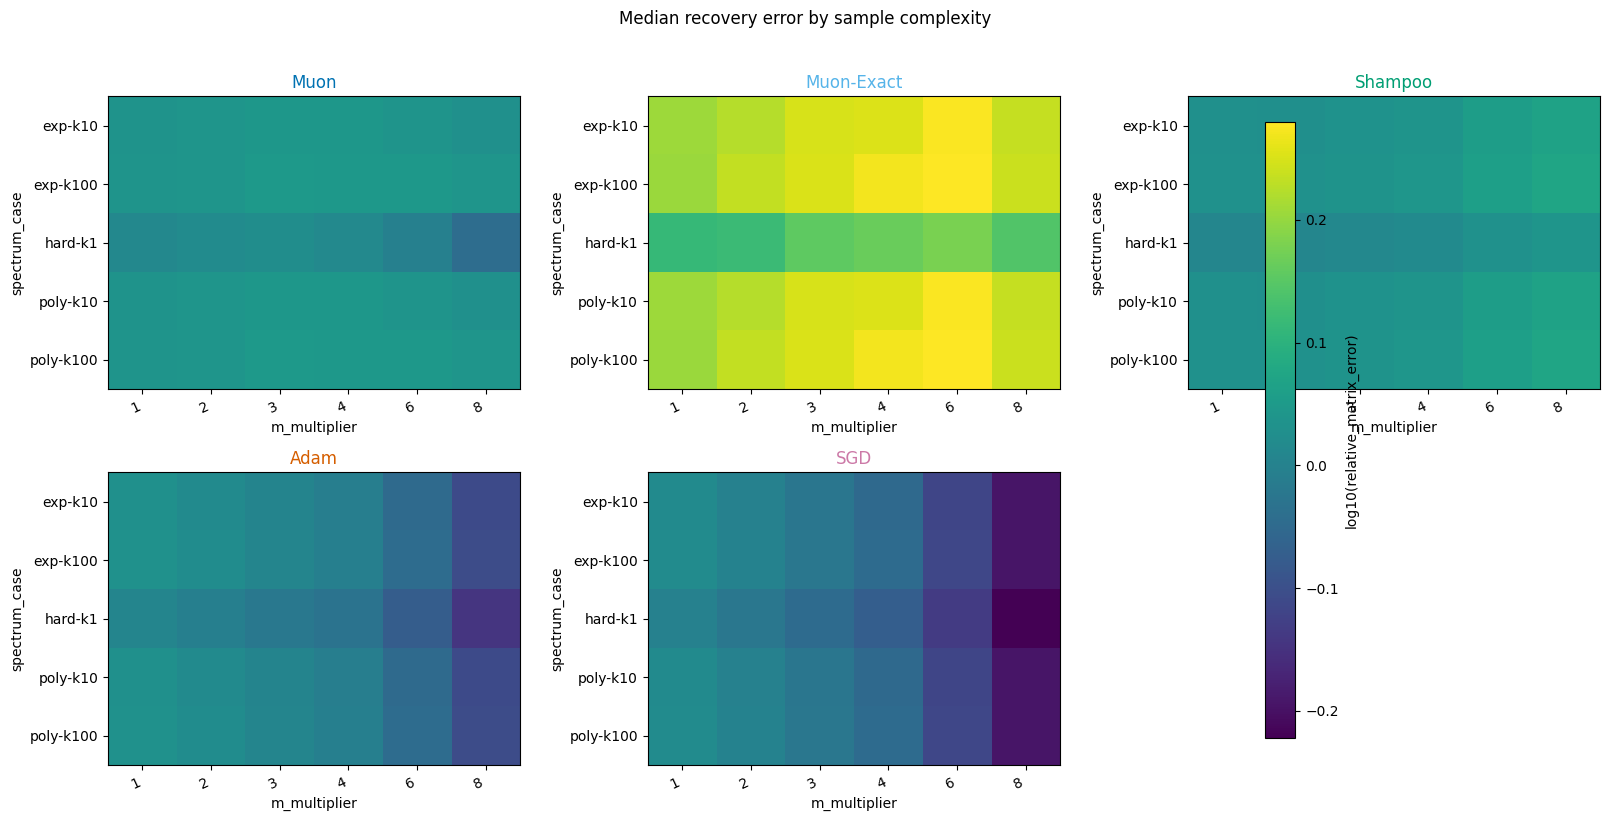

In [6]:
fig, axes = plotting.plot_optimizer_heatmaps(
    run_summary,
    x="m_multiplier",
    y="spectrum_case",
    metric="relative_matrix_error",
    title="Median recovery error by sample complexity",
    log_color=True,
)
show_figure(fig)


### Muon Gap Heatmaps

The Problem cell asks whether optimizers differ in undersampled or ill-conditioned regimes; these gap heatmaps answer that question relative to Adam and Shampoo.

These heatmaps keep the same $\alpha$-by-spectrum grid but replace absolute error with a method gap. The color is $\Delta_{\mathrm{Muon},b}=\log_{10}(e_{\mathrm{Muon}})-\log_{10}(e_b)$, where $b$ is Adam in the first figure and Shampoo in the second. Negative cells mean Muon has lower median recovery error; positive cells mean the baseline has lower median recovery error. The magnitude is in orders of magnitude, so $-1$ means roughly a tenfold Muon advantage.

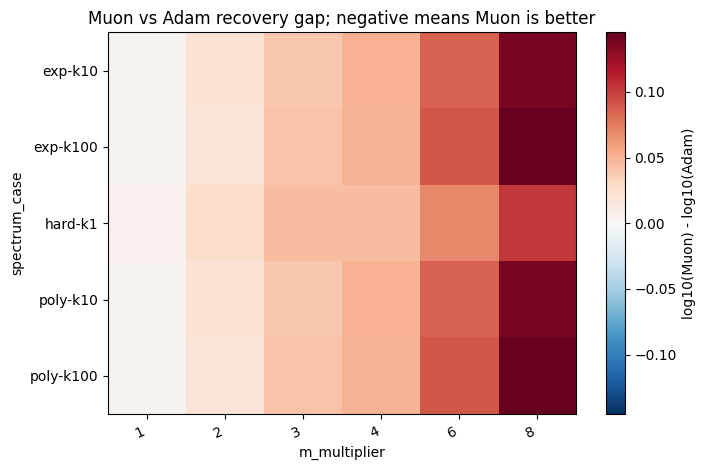

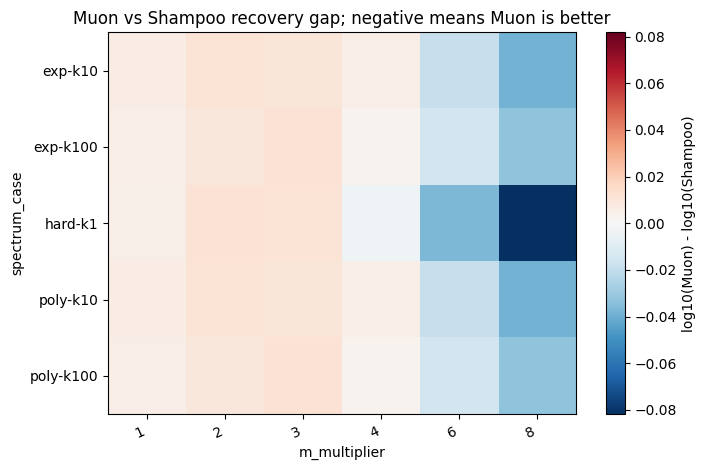

In [7]:
fig, ax = plotting.plot_gap_heatmap(
    run_summary,
    x="m_multiplier",
    y="spectrum_case",
    metric="relative_matrix_error",
    left_algo="Muon",
    right_algo="Adam",
    title="Muon vs Adam recovery gap; negative means Muon is better",
)
show_figure(fig)

fig, ax = plotting.plot_gap_heatmap(
    run_summary,
    x="m_multiplier",
    y="spectrum_case",
    metric="relative_matrix_error",
    left_algo="Muon",
    right_algo="Shampoo",
    title="Muon vs Shampoo recovery gap; negative means Muon is better",
)
show_figure(fig)


### Representative Loss Curves

The Problem cell warns that larger $\alpha$ changes both information and cost; these selected cells show the training-loss dynamics behind specific phase-diagram regimes.

The three panels are hand-picked cells from the heatmap: an easy high-sample case, a hard but learnable case, and an undersampled ill-conditioned case. Within each panel, the horizontal axis is step $t$, the vertical axis is median training loss $f(X_t)$ over seeds, and color is optimizer. These curves explain the optimization dynamics behind selected phase-diagram cells, but they do not by themselves prove recovery because the loss is measured on the training measurements.

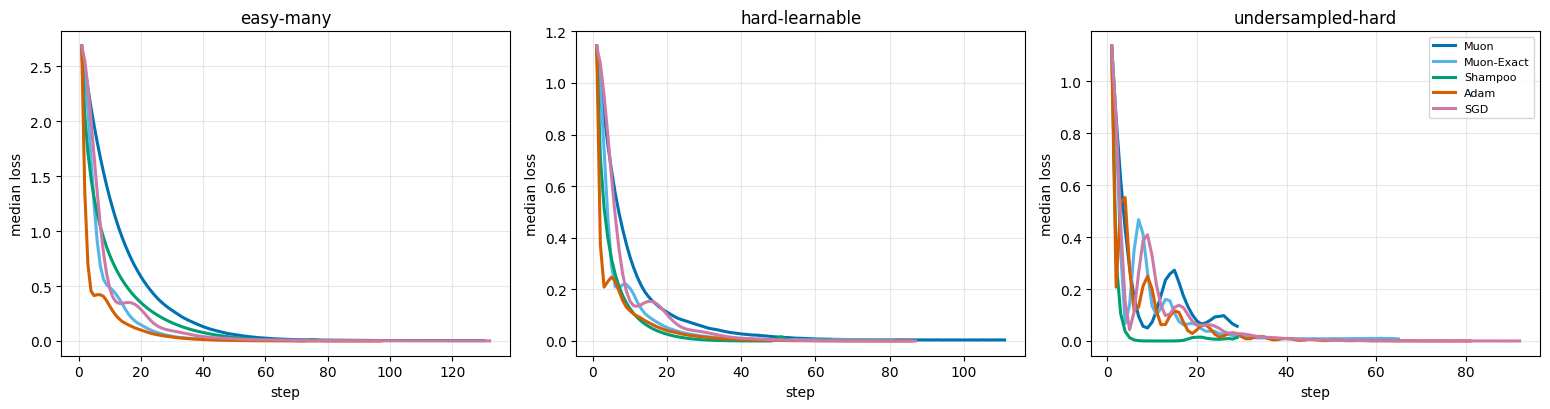

In [8]:
REPRESENTATIVE = [
    ("easy-many", "hard-k1", 8),
    ("hard-learnable", "exp-k100", 6),
    ("undersampled-hard", "exp-k100", 1),
]
fig, axes = plt.subplots(1, len(REPRESENTATIVE), figsize=(5.2 * len(REPRESENTATIVE), 4.2), sharey=False)
for ax, (label, spectrum_case, m_multiplier) in zip(axes, REPRESENTATIVE):
    sub = runs[(runs["spectrum_case"] == spectrum_case) & (runs["m_multiplier"] == m_multiplier)]
    for algo in ALGOS:
        curve = sub[sub["algo"] == algo].groupby("step", as_index=False)["loss"].median()
        ax.plot(curve["step"], curve["loss"], color=plotting.algorithm_color(algo), linewidth=2.2, label=algo)
    ax.set_title(label)
    ax.set_xlabel("step")
    ax.set_ylabel("median loss")
    ax.grid(alpha=0.3)
axes[-1].legend(fontsize=8)
fig.tight_layout()
show_figure(fig)


### Representative Log-Loss Curves

This is the same Problem-cell regime selection as above, but the log loss scale makes late optimization differences visible.

This repeats the same three representative regimes with a logarithmic loss axis. The dimensions are unchanged: panel is regime, horizontal axis is step, color is optimizer, and the vertical value is median training loss. Use this version to compare convergence rates and late-time gaps that are compressed in the linear plot.

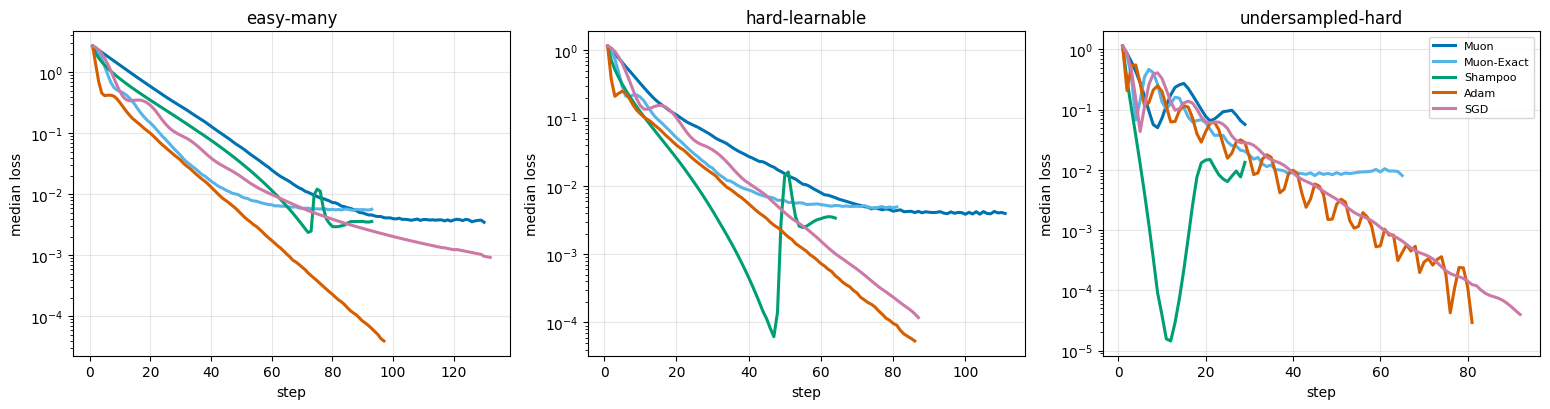

In [9]:
fig, axes = plt.subplots(1, len(REPRESENTATIVE), figsize=(5.2 * len(REPRESENTATIVE), 4.2), sharey=False)
for ax, (label, spectrum_case, m_multiplier) in zip(axes, REPRESENTATIVE):
    sub = runs[(runs["spectrum_case"] == spectrum_case) & (runs["m_multiplier"] == m_multiplier)]
    for algo in ALGOS:
        curve = sub[sub["algo"] == algo].groupby("step", as_index=False)["loss"].median()
        ax.plot(curve["step"], curve["loss"], color=plotting.algorithm_color(algo), linewidth=2.2, label=algo)
    ax.set_title(label)
    ax.set_xlabel("step")
    ax.set_ylabel("median loss")
    ax.set_yscale("log")
    ax.grid(alpha=0.3)
axes[-1].legend(fontsize=8)
fig.tight_layout()
show_figure(fig)


### Representative Recovery Curves

The Problem cell says recovery error, not just training loss, is the primary statistic; these curves track that recovery quantity over optimization time.

These panels use the same representative regimes as the loss curves, but the vertical axis is median recovery error $e_t=\lVert X_t-X^\star\rVert_F/\lVert X^\star\rVert_F$ on a log scale. This is the diagnostic that connects optimization to the actual statistical goal. If loss decreases while $e_t$ stalls, the optimizer is fitting measurements without improving the matrix estimate.

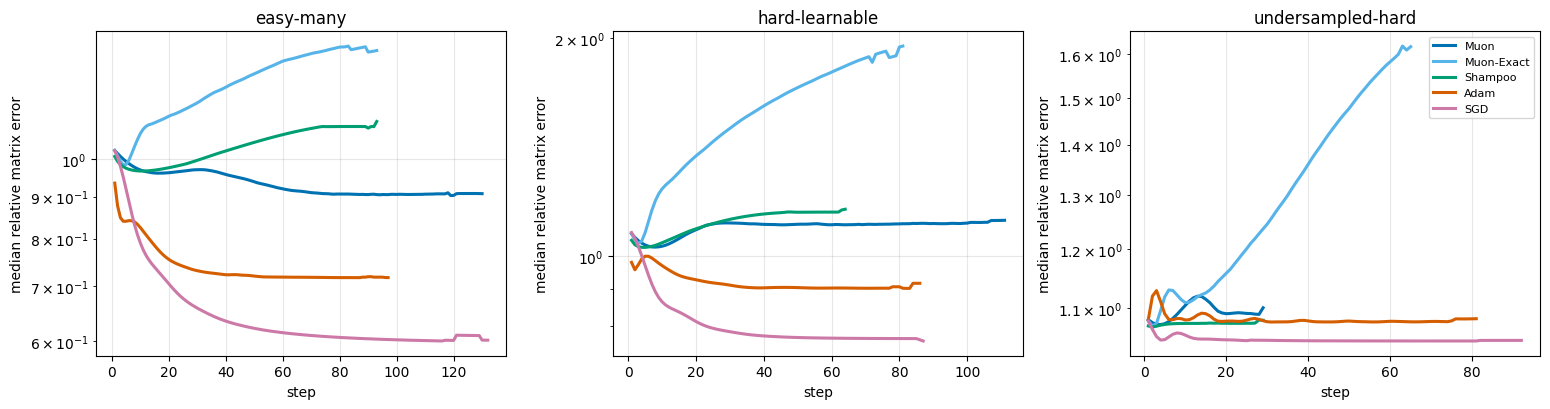

In [10]:
fig, axes = plt.subplots(1, len(REPRESENTATIVE), figsize=(5.2 * len(REPRESENTATIVE), 4.2), sharey=False)
for ax, (label, spectrum_case, m_multiplier) in zip(axes, REPRESENTATIVE):
    sub = runs[(runs["spectrum_case"] == spectrum_case) & (runs["m_multiplier"] == m_multiplier)]
    for algo in ALGOS:
        curve = sub[sub["algo"] == algo].groupby("step", as_index=False)["relative_matrix_error"].median()
        ax.plot(curve["step"], curve["relative_matrix_error"], color=plotting.algorithm_color(algo), linewidth=2.2, label=algo)
    ax.set_title(label)
    ax.set_xlabel("step")
    ax.set_ylabel("median relative matrix error")
    ax.set_yscale("log")
    ax.grid(alpha=0.3)
axes[-1].legend(fontsize=8)
fig.tight_layout()
show_figure(fig)


### Success Probability

The Problem cell frames $\alpha$ as sample complexity; this plot turns recovery into an empirical success probability as $\alpha$ increases.

Each generated figure fixes one spectrum case and plots the empirical phase transition in $\alpha$. The horizontal axis is $\alpha$ in $m=\alpha dr$, color is optimizer, and the vertical axis is $\Pr(e(\widehat X)\le 10^{-2})$, estimated as the seed average of the success indicator. This view collapses the heatmap into a probability curve: steep rises indicate a sharp sample-complexity threshold.

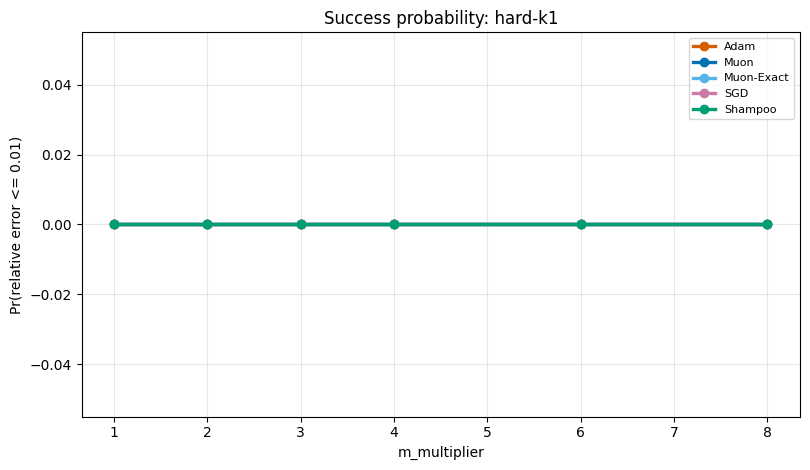

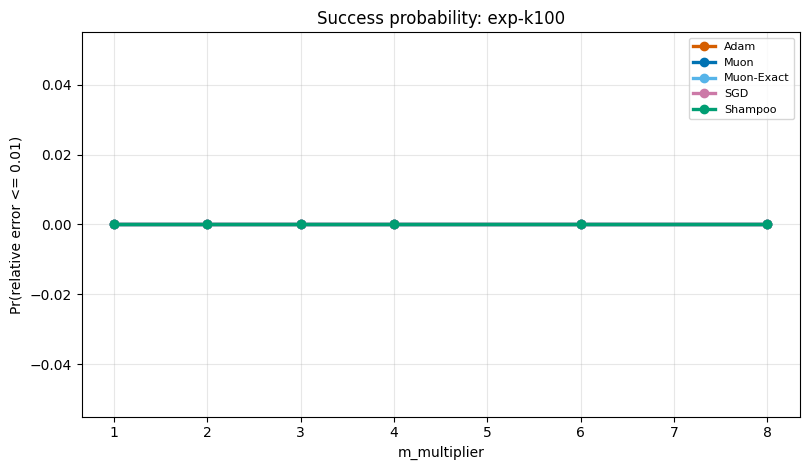

In [11]:
sub_success = success[success["spectrum_case"].isin(["hard-k1", "exp-k100"])]
for spectrum_case in ["hard-k1", "exp-k100"]:
    fig, ax = plotting.plot_metric_lines(
        sub_success[sub_success["spectrum_case"] == spectrum_case],
        x="m_multiplier",
        metric="success_probability",
        title=f"Success probability: {spectrum_case}",
        ylabel=f"Pr(relative error <= {SUCCESS_THRESHOLD:g})",
    )
    show_figure(fig)


### Best-Regime Table


In [12]:
setting_summary = run_summary.groupby(["spectrum_case", "m_multiplier", "algo"], as_index=False, observed=True).agg(
    median_error=("relative_matrix_error", "median"),
    median_loss=("final_loss", "median"),
    divergence_rate=("diverged", "mean"),
    median_time_per_step=("time_per_step", "median"),
)
best_by_setting = setting_summary.sort_values("median_error").groupby(["spectrum_case", "m_multiplier"], as_index=False, observed=True).first()
IPython.display.display(best_by_setting)


,spectrum_case,m_multiplier,algo,median_error,median_loss,divergence_rate,median_time_per_step
0,exp-k10,1,SGD,1.042739,0.046531,0.0,0.001923
1,exp-k10,2,SGD,0.996241,0.000077,0.0,0.002980
2,exp-k10,3,SGD,0.944448,0.000058,0.0,0.004883
3,exp-k10,4,SGD,0.891287,0.000099,0.0,0.006750
4,exp-k10,6,SGD,0.764449,0.000162,0.0,0.013088
5,exp-k10,8,SGD,0.638907,0.000735,0.0,0.015433
6,exp-k100,1,SGD,1.046831,0.044368,0.0,0.001260
7,exp-k100,2,SGD,1.001803,0.000081,0.0,0.003285
8,exp-k100,3,SGD,0.949391,0.000064,0.0,0.005422
9,exp-k100,4,SGD,0.896211,0.000047,0.0,0.007622


### Reading The Result

The primary comparison is the recovery-error gap heatmap. Negative Muon-vs-baseline values mean Muon has lower median recovery error. If Muon's advantage appears only at large `m_multiplier`, the result supports the sample-complexity hypothesis; if Muon also wins at `m_multiplier=1`, it may be acting as implicit regularization.
